# Exercício 2 — Não-linearidade em dimensões mais altas

Dois datasets 5D com a mesma dimensionalidade e estruturas bem diferentes: gaussianas
deslocadas (Dataset I) contra cascas concêntricas (Dataset II). A pergunta de fundo:
o que medidas *lineares* conseguem enxergar em cada um?

Mesma seed do começo ao fim: `rng = np.random.default_rng(42)`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

rng = np.random.default_rng(42)  # mesma seed em todo o notebook

# identidade visual dos meus gráficos: paleta fixa + eixos limpos
CORES = ["#E8A13D", "#C75146", "#6B8F3D", "#33658A"]  # âmbar, telha, oliva, aço
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.prop_cycle": plt.cycler(color=CORES),
    "figure.dpi": 110,
})

## A — Dataset I: gaussianas deslocadas

In [2]:
mu_A = np.zeros(5)
mu_B = np.full(5, 1.5)

Sigma_A = np.array([
    [1.0, 0.8, 0.1, 0.0, 0.0],
    [0.8, 1.0, 0.3, 0.0, 0.0],
    [0.1, 0.3, 1.0, 0.5, 0.0],
    [0.0, 0.0, 0.5, 1.0, 0.2],
    [0.0, 0.0, 0.0, 0.2, 1.0],
])
Sigma_B = np.array([
    [ 1.5, -0.7, 0.2, 0.0, 0.0],
    [-0.7,  1.5, 0.4, 0.0, 0.0],
    [ 0.2,  0.4, 1.5, 0.6, 0.0],
    [ 0.0,  0.0, 0.6, 1.5, 0.3],
    [ 0.0,  0.0, 0.0, 0.3, 1.5],
])

X_A = rng.multivariate_normal(mu_A, Sigma_A, 500)
X_B = rng.multivariate_normal(mu_B, Sigma_B, 500)
print("Dataset I:", X_A.shape, X_B.shape)

Dataset I: (500, 5) (500, 5)


Repare que as dispersões são diferentes de propósito: $\Sigma_B$ tem variâncias
maiores (1.5 contra 1.0) e correlação **negativa** entre as duas primeiras features
(−0.7), enquanto em $\Sigma_A$ ela é positiva (+0.8).

## B — Dataset II: cascas concêntricas

Sorteio uma direção uniforme na esfera unitária de $\mathbb{R}^5$
($v \sim \mathcal{N}(0, I_5)$, $u = v/\lVert v \rVert$) e multiplico por um raio
gaussiano: $x = \rho \cdot u$. O `0.4` do enunciado eu tratei como
**desvio-padrão** do raio.

In [3]:
# Classe C (núcleo): raio ~ N(2.0, 0.4)
v = rng.normal(size=(500, 5))
u = v / np.linalg.norm(v, axis=1, keepdims=True)  # direção na esfera unitária
rho = rng.normal(2.0, 0.4, 500)
X_C = rho[:, None] * u

# Classe D (casca): mesmo processo, raio ~ N(5.0, 0.4)
v = rng.normal(size=(500, 5))
u = v / np.linalg.norm(v, axis=1, keepdims=True)
rho = rng.normal(5.0, 0.4, 500)
X_D = rho[:, None] * u

print("Dataset II:", X_C.shape, X_D.shape)

Dataset II: (500, 5) (500, 5)


## C — Visualizar e comparar

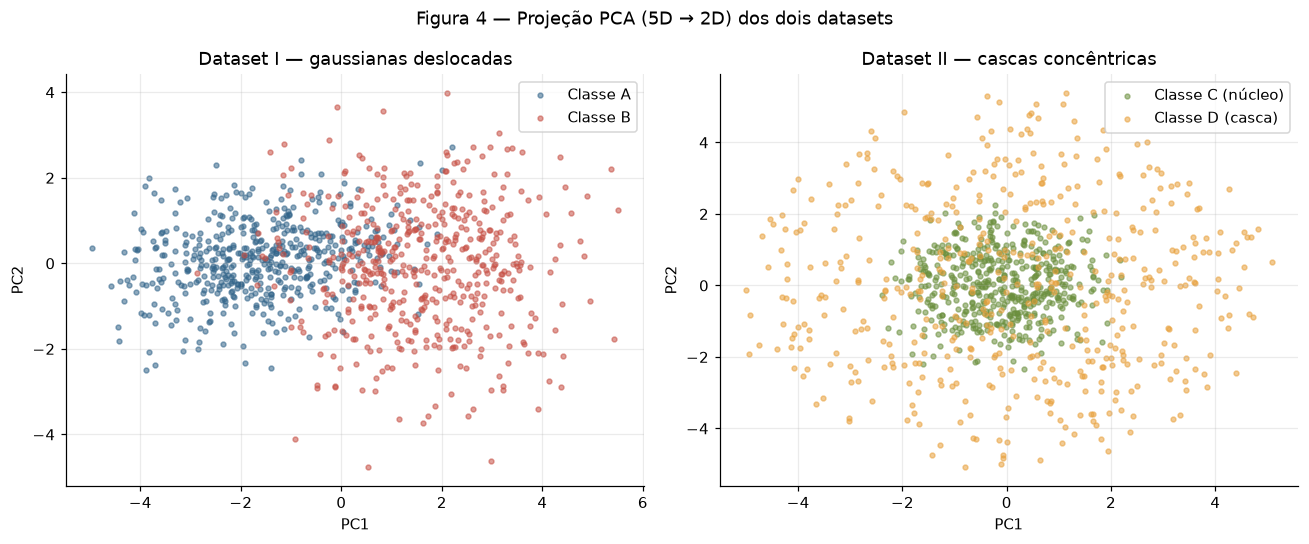

Variância explicada Dataset I : PC1 = 0.5004, PC2 = 0.1593, soma = 0.6597
Variância explicada Dataset II: PC1 = 0.2159, PC2 = 0.2132, soma = 0.4291


In [4]:
# PCA por dataset (ajustado sobre as duas classes juntas)
pca_1 = PCA(n_components=2).fit(np.vstack([X_A, X_B]))
pca_2 = PCA(n_components=2).fit(np.vstack([X_C, X_D]))
P_A, P_B = pca_1.transform(X_A), pca_1.transform(X_B)
P_C, P_D = pca_2.transform(X_C), pca_2.transform(X_D)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(P_A[:, 0], P_A[:, 1], s=10, alpha=0.55, color=CORES[3], label="Classe A")
axes[0].scatter(P_B[:, 0], P_B[:, 1], s=10, alpha=0.55, color=CORES[1], label="Classe B")
axes[0].set_title("Dataset I — gaussianas deslocadas")
axes[1].scatter(P_C[:, 0], P_C[:, 1], s=10, alpha=0.55, color=CORES[2],
                label="Classe C (núcleo)")
axes[1].scatter(P_D[:, 0], P_D[:, 1], s=10, alpha=0.55, color=CORES[0],
                label="Classe D (casca)")
axes[1].set_title("Dataset II — cascas concêntricas")
for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
fig.suptitle("Figura 4 — Projeção PCA (5D → 2D) dos dois datasets")
plt.tight_layout()
plt.show()

evr_1 = pca_1.explained_variance_ratio_
evr_2 = pca_2.explained_variance_ratio_
print(f"Variância explicada Dataset I : PC1 = {evr_1[0]:.4f}, PC2 = {evr_1[1]:.4f}, "
      f"soma = {evr_1.sum():.4f}")
print(f"Variância explicada Dataset II: PC1 = {evr_2[0]:.4f}, PC2 = {evr_2[1]:.4f}, "
      f"soma = {evr_2.sum():.4f}")

Distância entre centros (5D) — Dataset I : 3.2282
Distância entre centros (5D) — Dataset II: 0.2662


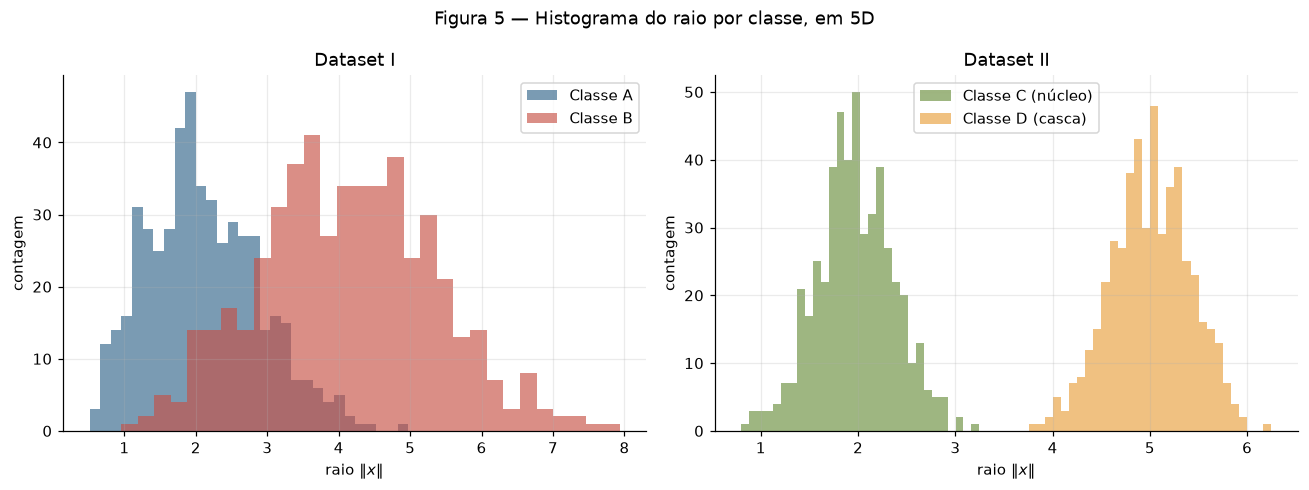

Raios Dataset II — C: 1.97 ± 0.40 (máx 3.25) | D: 5.00 ± 0.41 (mín 3.75)


In [5]:
# Medidas geométricas em 5D
dist_1 = np.linalg.norm(X_A.mean(axis=0) - X_B.mean(axis=0))
dist_2 = np.linalg.norm(X_C.mean(axis=0) - X_D.mean(axis=0))
print(f"Distância entre centros (5D) — Dataset I : {dist_1:.4f}")
print(f"Distância entre centros (5D) — Dataset II: {dist_2:.4f}")

r_A = np.linalg.norm(X_A, axis=1)
r_B = np.linalg.norm(X_B, axis=1)
r_C = np.linalg.norm(X_C, axis=1)
r_D = np.linalg.norm(X_D, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(r_A, bins=30, alpha=0.65, color=CORES[3], label="Classe A")
axes[0].hist(r_B, bins=30, alpha=0.65, color=CORES[1], label="Classe B")
axes[0].set_title("Dataset I")
axes[1].hist(r_C, bins=30, alpha=0.65, color=CORES[2], label="Classe C (núcleo)")
axes[1].hist(r_D, bins=30, alpha=0.65, color=CORES[0], label="Classe D (casca)")
axes[1].set_title("Dataset II")
for ax in axes:
    ax.set_xlabel("raio $\\|x\\|$")
    ax.set_ylabel("contagem")
    ax.legend()
fig.suptitle("Figura 5 — Histograma do raio por classe, em 5D")
plt.tight_layout()
plt.show()

print(f"Raios Dataset II — C: {r_C.mean():.2f} ± {r_C.std():.2f} "
      f"(máx {r_C.max():.2f}) | D: {r_D.mean():.2f} ± {r_D.std():.2f} "
      f"(mín {r_D.min():.2f})")

**Os números.** Variância explicada por PC1+PC2: **0.6597** no Dataset I
(PC1 = 0.5004, PC2 = 0.1593) contra **0.4291** no Dataset II
(PC1 = 0.2159, PC2 = 0.2132). Distância entre centros em 5D: **3.2282** no Dataset I
(o teórico é $1.5\sqrt{5} = 3.354$) contra **0.2662** no Dataset II.

A projeção 2D preserva melhor a informação de classe no **Dataset I**: o deslocamento
entre as médias cria uma direção privilegiada de variância, e o PCA a captura em PC1 —
na Figura 4 dá para ver dois blocos com sobreposição parcial. No Dataset II a
variância é praticamente a mesma em toda direção (PC1 ≈ PC2 ≈ 21.5%, o esperado para
dados isotrópicos em 5D) e a projeção vira um borrão com as classes misturadas —
enquanto a Figura 5 mostra que, em 5D, os raios são perfeitamente separados
(C: 1.97 ± 0.40, máx 3.25; D: 5.00 ± 0.41, mín 3.75). Os histogramas nem se encostam.

## D — Análise

**1. Centros coincidentes × raios separados.** A distância entre os centros do
Dataset II é 0.2662 (≈ 0), mas os histogramas de raio têm um vão entre 3.25 e 3.75.
Um hiperplano separa por *posição ao longo de uma direção* — e as duas classes ocupam
as mesmas posições em todas as direções, diferindo só na *distância à origem*.
Conclusão: hiperplano nenhum separa essas classes; a informação discriminante é
radial, não direcional.

**2. Por que mais dados não salvam.** Por simetria esférica, a projeção de cada
classe sobre **qualquer** direção $w$ é simétrica em torno de zero, e as projeções
das duas classes se sobrepõem fortemente. Coletar mais dados só estima melhor essas
mesmas distribuições sobrepostas — o erro de qualquer fronteira linear continua alto.
A limitação é da *família de fronteiras*, não da amostra.

**3. Projeção PCA embolada prova inseparabilidade?** Não — e o Dataset II é o
contraexemplo perfeito. O PCA é uma transformação **linear**: a projeção 2D é um
borrão (PC1+PC2 = 42.9%), mas basta uma função não-linear simples das entradas para
separar tudo:

$$ f(x) = \lVert x \rVert^2 = \sum_{i=1}^{5} x_i^2, \qquad
\text{classe C se } f(x) < 3.5^2 = 12.25 $$

In [6]:
# Conferindo a função proposta (regra fixa — nada é treinado)
f_C = (X_C ** 2).sum(axis=1)
f_D = (X_D ** 2).sum(axis=1)
acerto = ((f_C < 12.25).sum() + (f_D >= 12.25).sum()) / 1000
print(f"Regra f(x) = Σx² < 12.25 → acurácia na amostra: {acerto:.4f}")

Regra f(x) = Σx² < 12.25 → acurácia na amostra: 1.0000


A regra $\sum_i x_i^2 < 12.25$ acerta **100%** das 1000 amostras. O mesmo dado que
parece impossível sob qualquer lente linear fica trivial depois de uma única
transformação quadrática — que é exatamente o tipo de feature que as camadas
escondidas de uma rede aprendem sozinhas.

---

> **O que eu tiro daqui:** distância entre centros não mede separabilidade, e
> ferramenta linear (PCA, hiperplano) não consegue nem *diagnosticar* estrutura
> não-linear. A separabilidade do Dataset II estava na representação
> ($\lVert x \rVert^2$), não nos dados — e é isso que justifica camadas escondidas
> com ativação não-linear.